## 📚 Module 09: Data Preprocessing & Feature Engineering — সম্পূর্ণ বাংলা গাইড

📌 1. Missing Values (অনুপস্থিত মান) — Titanic Dataset
🔸 বাস্তব উপমা: হাজিরা খাতা

মনে করো স্কুলের হাজিরা খাতায় কিছু ঘর খালি। যদি সেই খালি ঘরগুলো হিসাব না করি, উপস্থিতির হার ভুল আসবে। তাই আমাদের সিদ্ধান্ত নিতে হবে খালি ঘরগুলো নিয়ে কী করব।

Titanic dataset-এ:

### Age — numeric column এ missing values আছে
### Embarked — categorical column এ ২টি missing values আছে
### Cabin — এত বেশি missing যে বাদ দেওয়াই ভালো

আমরা করব:

Missing values পর্যবেক্ষণ
Age → Median দিয়ে পূরণ করব (কারণ skewed distribution)
Embarked → Mode দিয়ে পূরণ করব
Cabin → সম্পূর্ণ বাদ দেব

In [12]:
import pandas as pd

titanic_path = "Titanic-Dataset.csv"
df_titanic = pd.read_csv(titanic_path)
df_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [13]:
shape = df_titanic.shape
print("আউটপুট: (891, 12) — মানে ৮৯১ যাত্রী, ১২টি column।",shape)

আউটপুট: (891, 12) — মানে ৮৯১ যাত্রী, ১২টি column। (891, 12)


In [16]:
print("Unique values per column:")
df_titanic.nunique()

Unique values per column:


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [17]:
print("Missing values per column:")
df_titanic.isnull().sum()

Missing values per column:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

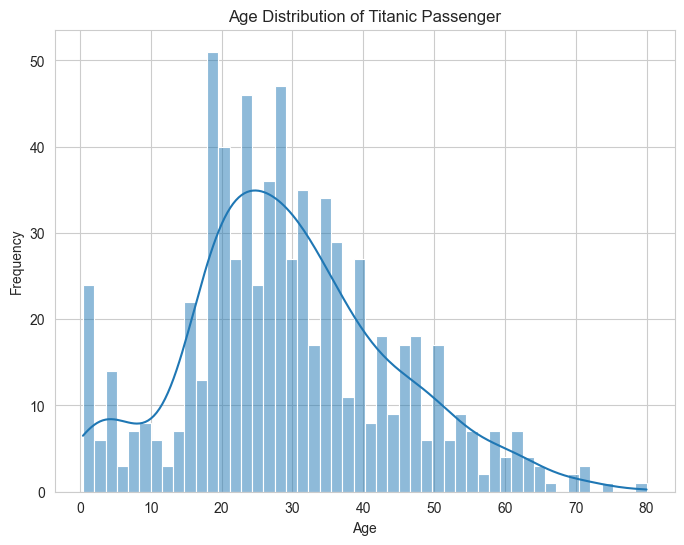

'\n"ব্যাখ্যা: Histogram দেখে বোঝা যাচ্ছে Age distribution right-skewed (ডানদিকে লেজ আছে)\nSkewed data-তে Median সঠিক central tendency\nMean ব্যবহার করলে outlier-দের কারণে বিকৃত হবে")##\n'

In [28]:
#💻 কোড ৫: Age Column-এর Distribution দেখা

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(df_titanic["Age"], kde=True, bins=50)
plt.title("Age Distribution of Titanic Passenger")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
"""
"ব্যাখ্যা: Histogram দেখে বোঝা যাচ্ছে Age distribution right-skewed (ডানদিকে লেজ আছে)
Skewed data-তে Median সঠিক central tendency
Mean ব্যবহার করলে outlier-দের কারণে বিকৃত হবে")##
"""

In [ ]:
#💻 কোড ৬: Embarked Column-এর Distribution দেখা

print()